In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Connect to database
BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))
DB_PATH  = os.path.join(BASE_DIR, "data", "raw", "financials.db")
engine   = create_engine(f"sqlite:///{DB_PATH}")

# Load feature table
df = pd.read_sql("SELECT * FROM features", engine)

# Define feature columns
RATIO_COLS  = [
    "current_ratio", "quick_ratio", "cash_ratio",
    "debt_to_equity", "interest_coverage", "debt_to_ebitda",
    "gross_margin", "ebitda_margin", "net_margin",
    "roe", "roa", "operating_cf_ratio", "cf_to_debt", "fcf_margin"
]
DELTA_COLS  = [f"delta_{c}"  for c in RATIO_COLS]
ZSCORE_COLS = [f"zscore_{c}" for c in RATIO_COLS]
FEATURE_COLS = RATIO_COLS + DELTA_COLS + ZSCORE_COLS

# Define X and y
X = df[FEATURE_COLS]
y = df["health_score"] - 1  # XGBoost needs 0-indexed: 0-4 not 1-5

print(f"Features shape: {X.shape}")
print(f"Class distribution (0=Distressed, 4=Excellent):")
print(y.value_counts().sort_index())

Features shape: (60, 42)
Class distribution (0=Distressed, 4=Excellent):
health_score
0     7
1     3
2     2
3    10
4    38
Name: count, dtype: int64


In [16]:
#Training 3 models, namely the Logistic Regression, Random Forest and XGB Classifire
from sklearn.impute import SimpleImputer

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Fill NaN values with median
imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)

print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows\n")

# Define 3 models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, class_weight="balanced"),
    "Random Forest":       RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
    "XGBoost":             XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                                         subsample=0.8, colsample_bytree=0.8,
                                         eval_metric="mlogloss", random_state=42),
}

results = {}

for name, clf in models.items():
    clf.fit(X_train, y_train)
    pred = clf.predict(X_test)
    f1   = f1_score(y_test, pred, average="macro", zero_division=0)
    results[name] = {"model": clf, "pred": pred}
    print(f"{'='*45}")
    print(f"{name}  |  F1 (macro): {f1:.3f}")
    print(f"{'='*45}")
    print(classification_report(y_test, pred,
                                target_names=["Distressed","Weak","Neutral","Good","Excellent"],
                                labels=[0, 1, 2, 3, 4],
                                zero_division=0))

Train: 48 rows | Test: 12 rows

Logistic Regression  |  F1 (macro): 0.175
              precision    recall  f1-score   support

  Distressed       0.00      0.00      0.00         1
        Weak       0.00      0.00      0.00         1
     Neutral       0.00      0.00      0.00         0
        Good       0.00      0.00      0.00         2
   Excellent       0.88      0.88      0.88         8

    accuracy                           0.58        12
   macro avg       0.17      0.17      0.17        12
weighted avg       0.58      0.58      0.58        12

Random Forest  |  F1 (macro): 0.569
              precision    recall  f1-score   support

  Distressed       0.50      1.00      0.67         1
        Weak       0.00      0.00      0.00         1
     Neutral       0.00      0.00      0.00         0
        Good       1.00      0.50      0.67         2
   Excellent       0.89      1.00      0.94         8

    accuracy                           0.83        12
   macro avg       0.

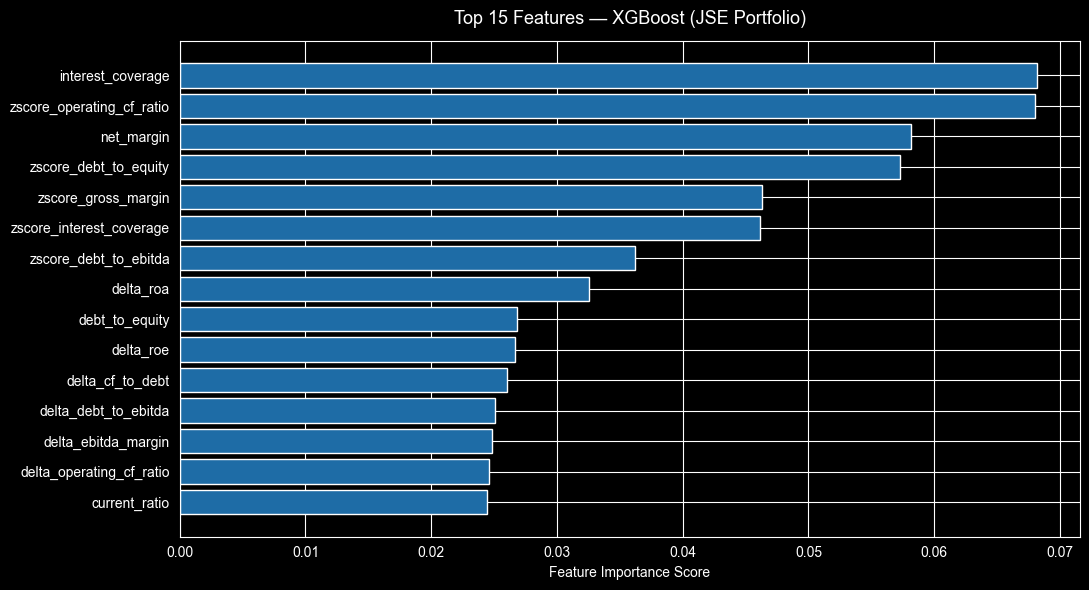


Top 5 most important features:
interest_coverage            0.068192
zscore_operating_cf_ratio    0.068021
net_margin                   0.058154
zscore_debt_to_equity        0.057272
zscore_gross_margin          0.046323
dtype: float32


In [14]:
# Feature importance from XGBoost (Importance Chart)
xgb = results["XGBoost"]["model"]
importance = pd.Series(xgb.feature_importances_, index=FEATURE_COLS)
importance = importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(11, 6))
plt.barh(importance.index[::-1], importance.values[::-1], color="#1E6CA6")
plt.title("Top 15 Features — XGBoost (JSE Portfolio)", fontsize=13, pad=12)
plt.xlabel("Feature Importance Score")
plt.tight_layout()

# Save chart
chart_path = os.path.join(BASE_DIR, "data", "processed", "feature_importance.png")
plt.savefig(chart_path, dpi=150)
plt.show()

print(f"\nTop 5 most important features:")
print(importance.head(5))

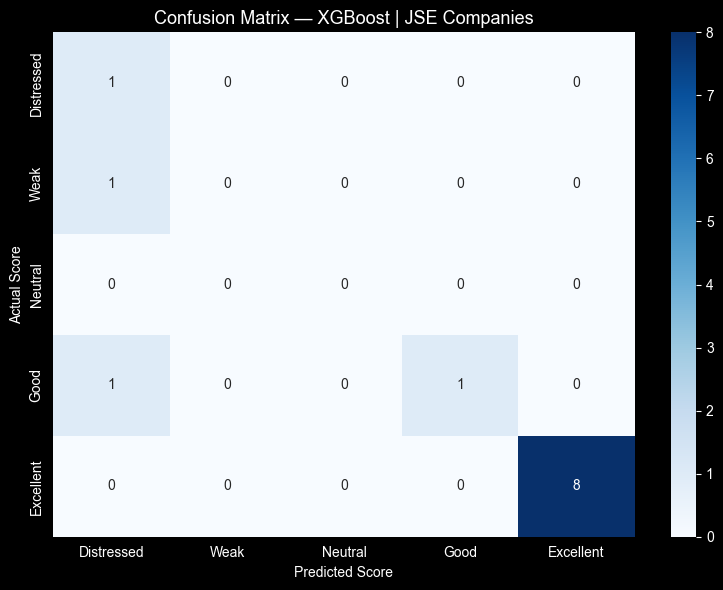

In [17]:
#The Confusion matrix
labels = ["Distressed", "Weak", "Neutral", "Good", "Excellent"]
cm = confusion_matrix(y_test, results["XGBoost"]["pred"], labels=[0,1,2,3,4])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_title("Confusion Matrix — XGBoost | JSE Companies", fontsize=13)
ax.set_ylabel("Actual Score")
ax.set_xlabel("Predicted Score")
plt.tight_layout()

# Save chart
cm_path = os.path.join(BASE_DIR, "data", "processed", "confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
plt.show()